In [22]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

In [23]:
from sklearn.preprocessing import LabelEncoder

# Load the preprocessed dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MAI391_Project/hcm_weather_preprocessed.csv')

# Ensure 'Date' is a datetime object and sort the dataset chronologically
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Define the features (X) and the target variable (y)
feature_cols = ['Temp', 'Feels', 'Wind', 'Gust', 'Rain', 'Humidity', 'Cloud', 'Pressure', 'Vis', 'Month']
X = df[feature_cols]
y = df['Target_Next_Day_Label']

# Chronological Train/Test Split (80% Training, 20% Testing) BEFORE encoding
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

# FIX: Fit LabelEncoder ONLY on the training targets
label_encoder = LabelEncoder()
y_train = pd.Series(label_encoder.fit_transform(y_train), name='Target_Next_Day_Label')

# Filter out rare weather conditions in the test set that the model never saw during training
# (We cannot test the model on things it hasn't learned)
valid_test_indices = y_test.isin(label_encoder.classes_)
X_test = X_test[valid_test_indices].reset_index(drop=True)
y_test = y_test[valid_test_indices]

# Transform the cleaned test set labels
y_test = pd.Series(label_encoder.transform(y_test), name='Target_Next_Day_Label')

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Perfectly continuous unique classes in y_train: {np.unique(y_train)}")

Training data shape: (3496, 10)
Testing data shape: (868, 10)
Perfectly continuous unique classes in y_train: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


In [24]:
# Initialize the XGBoost Classifier
# We use 'multi:softmax' for multi-class classification
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    eval_metric='mlogloss',
    random_state=42
)

# Train the model on the chronological training set
xgb_model.fit(X_train, y_train)

print("XGBoost model training complete.")

XGBoost model training complete.


In [25]:
# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# Calculate overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Display a detailed classification report
# zero_division=0 handles classes that might not appear in the test set predictions
print("Classification Report (Precision, Recall, F1-score):")
print(classification_report(y_test, y_pred, zero_division=0))

Model Accuracy: 47.58%

Classification Report (Precision, Recall, F1-score):
              precision    recall  f1-score   support

           0       0.09      0.40      0.14        42
           1       0.11      0.04      0.06        25
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         2
           6       0.50      0.02      0.03        66
           7       0.00      0.00      0.00         0
           8       0.18      0.03      0.05        64
          11       0.00      0.00      0.00         4
          12       0.63      0.69      0.65       570
          13       0.00      0.00      0.00         0
          14       0.00      0.00      0.00        69
          15       0.00      0.00      0.00        15
          16       0.00      0.00      0.00         6
          17       0.00      0.00      0.00         2

   

/tmp/ipykernel_6581/1006651337.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F_Score', y='Feature', data=importance_df, palette='viridis')


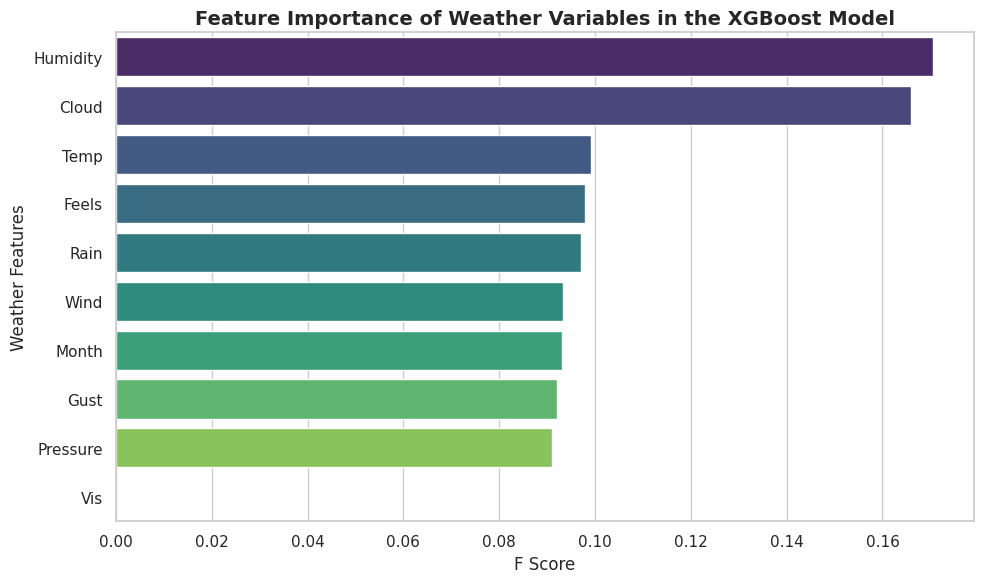

In [26]:
plt.figure(figsize=(10, 6))

# Extract feature importances from the trained XGBoost model
importances = xgb_model.feature_importances_

# Create a DataFrame for easier plotting
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'F_Score': importances
}).sort_values(by='F_Score', ascending=False)

# Plot the feature importances
sns.barplot(x='F_Score', y='Feature', data=importance_df, palette='viridis')

plt.title('Feature Importance of Weather Variables in the XGBoost Model', fontsize=14, fontweight='bold')
plt.xlabel('F Score', fontsize=12)
plt.ylabel('Weather Features', fontsize=12)

plt.tight_layout()
plt.show()